In [1]:
import os

# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics
import subprocess
import sys
import seaborn as sns
import numpy as np
from scipy.sparse import csr_matrix
import scanpy.external as sce
from sklearn.metrics import silhouette_score
import datetime
import numpy as np
import harmonypy as hm
import scanorama
import gffutils
from collections import defaultdict
import scipy.sparse as sp
from collections import defaultdict
import scipy.sparse as sp

# sys.path.append('../utils')
# from functions import * 

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

sns.set(style="whitegrid")

# Flag for whether to also read intron and exons files 
read_introns_exons = True

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation
scanpy==1.10.4 anndata==0.11.3 umap==0.5.6 numpy==1.26.4 scipy==1.14.1 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.2 igraph==0.11.5 louvain==0.8.2 pynndescent==0.5.12


In [2]:
# Load gene gtf file for gene length 
gtf_hg38 = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/gencode.v45.primary_assembly.annotation.gtf"
db_file = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/gencode_hg38.db"

WD="/gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/GeneExpression"
today = datetime.datetime.now()
today = today.strftime("%Y-%m-%d")

In [3]:
def extract_gene_transcript_info(gtf_file, db_file):
    """
    Parses a GENCODE GTF file to compute:
    - Mean transcript length per gene (sum of exons)
    - Mean intron length per gene (transcript span - exon length)
    - Number of transcripts per gene
    - Transcript biotypes
    - Gene name
    
    Returns a DataFrame with gene_id, gene_name, mean_transcript_length, mean_intron_length, 
    num_transcripts, and transcript_biotypes.
    """

    if os.path.exists(db_file):
        print("Using existing GTF database.")
        db = gffutils.FeatureDB(db_file, keep_order=True)
        print("Database loaded successfully!")
    else:
        print("Creating GTF database (this may take a few minutes)...")
        db = gffutils.create_db(
            gtf_file,
            db_file,
            force=True,
            keep_order=True,
            disable_infer_transcripts=False,
            disable_infer_genes=True
        )
        print("Database created successfully!")

    gene_exon_lengths = defaultdict(list)
    gene_intron_lengths = defaultdict(list)
    gene_names = {}
    gene_biotypes = defaultdict(set)
    transcript_counts = defaultdict(int)

    print("Processing transcripts to compute exon and intron lengths...")
    for transcript in tqdm(db.features_of_type("transcript"), desc="Processing Transcripts", unit=" transcript"):
        gene_id = transcript.attributes["gene_id"][0]
        gene_name = transcript.attributes.get("gene_name", ["unknown"])[0]
        transcript_biotype = transcript.attributes.get("transcript_type", ["unknown"])[0]

        exons = list(db.children(transcript, featuretype="exon", order_by="start"))
        if len(exons) == 0:
            continue  # skip transcripts with no exons

        exon_length = sum(exon.end - exon.start + 1 for exon in exons)
        transcript_start = exons[0].start
        transcript_end = exons[-1].end
        transcript_span = transcript_end - transcript_start + 1
        intron_length = transcript_span - exon_length  # includes gaps between exons

        gene_exon_lengths[gene_id].append(exon_length)
        gene_intron_lengths[gene_id].append(max(0, intron_length))  # avoid negative values
        gene_names[gene_id] = gene_name
        gene_biotypes[gene_id].add(transcript_biotype)
        transcript_counts[gene_id] += 1

    print("Finished processing transcripts.")

    gene_ids = list(gene_exon_lengths.keys())
    gene_info_df = pd.DataFrame({
        "gene_id": gene_ids,
        "gene_name": [gene_names[g] for g in gene_ids],
        "mean_transcript_length": [sum(gene_exon_lengths[g]) / len(gene_exon_lengths[g]) for g in gene_ids],
        "mean_intron_length": [sum(gene_intron_lengths[g]) / len(gene_intron_lengths[g]) for g in gene_ids],
        "num_transcripts": [transcript_counts[g] for g in gene_ids],
        "transcript_biotypes": [", ".join(sorted(gene_biotypes[g])) for g in gene_ids]
    })

    return gene_info_df

def preprocess_ab_adata(adata, metadata, dataset_label="allen_brain", 
                        metadata_key="sample_name", rename_var=True):
    """
    Standardizes Allen Brain adata object:
    - Subsets metadata to only matching cells
    - Renames gene info
    - Stores raw counts layer
    """
    adata = adata.copy()
    adata.var['gene_name'] = adata.var_names
    adata.obs["dataset"] = dataset_label

    # Use correct column to index metadata
    if metadata_key not in metadata.columns:
        raise ValueError(f"Metadata key '{metadata_key}' not found in metadata columns.")
    
    metadata_sub = metadata[metadata[metadata_key].isin(adata.obs_names)].copy()
    metadata_sub = metadata_sub.set_index(metadata_key)

    # Align metadata to adata
    adata = adata[adata.obs_names.isin(metadata_sub.index)].copy()
    adata.obs = metadata_sub.loc[adata.obs_names]

    # Rename gene_name -> gene_symbol
    if rename_var:
        adata.var.rename(columns={"gene_name": "gene_symbol"}, inplace=True)
    else:
        adata.var["gene_symbol"] = adata.var["gene_name"]
    adata.layers["raw_counts"] = adata.X.copy()
    return adata

### First, get gene info (average transcript length and average total intron length)

In [4]:
# Add gene length information to the adata object [done]
# follow recommended practices for smart-seq2 raw count normalization
# https://docs.scvi-tools.org/en/1.0.0/tutorials/notebooks/tabula_muris.html

# Load gene info
gene_info_df = extract_gene_transcript_info(gtf_hg38, db_file)
gene_info_df = gene_info_df.drop_duplicates(subset="gene_id")
gene_info_df = gene_info_df.drop_duplicates(subset="gene_name")

Using existing GTF database.
Database loaded successfully!
Processing transcripts to compute exon and intron lengths...


Processing Transcripts: 252989 transcript [01:13, 3431.38 transcript/s]


Finished processing transcripts.


### Prep the three anndata objects (total counts, exons only and introns only)

In [5]:
# Set up paths for files 
gene_exp = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/GeneExpression/matrix.csv" #intronic and exonic reads 
introns_only = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/GeneExpression/intron.csv"
exons_only = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/GeneExpression/exon.csv"

if read_introns_exons:
    ab_adata_introns = sc.read_csv(introns_only)
    ab_adata_introns = ab_adata_introns.transpose()
    print(f"Done reading {introns_only}")

    ab_adata_exons = sc.read_csv(exons_only)
    ab_adata_exons = ab_adata_exons.transpose()
    print(f"Done reading {exons_only}")
    
ab_adata = sc.read_csv(gene_exp)
print(f"Done reading {gene_exp}")

# Read in metadata
metadata = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/INFO/metadata.csv"
metadata = pd.read_csv(metadata)

# Process total counts normally (uses 'sample_name')
ab_adata = preprocess_ab_adata(ab_adata, metadata, metadata_key="sample_name")

# Process exon and intron counts (uses 'exp_component_name')
if read_introns_exons:
    ab_adata_exons = preprocess_ab_adata(ab_adata_exons, metadata, metadata_key="exp_component_name")
    ab_adata_introns = preprocess_ab_adata(ab_adata_introns, metadata, metadata_key="exp_component_name")

print("All AB datasets preprocessed with correct metadata mapping.")

Done reading /gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/GeneExpression/intron.csv
Done reading /gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/GeneExpression/exon.csv
Done reading /gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/GeneExpression/matrix.csv
All AB datasets preprocessed with correct metadata mapping.


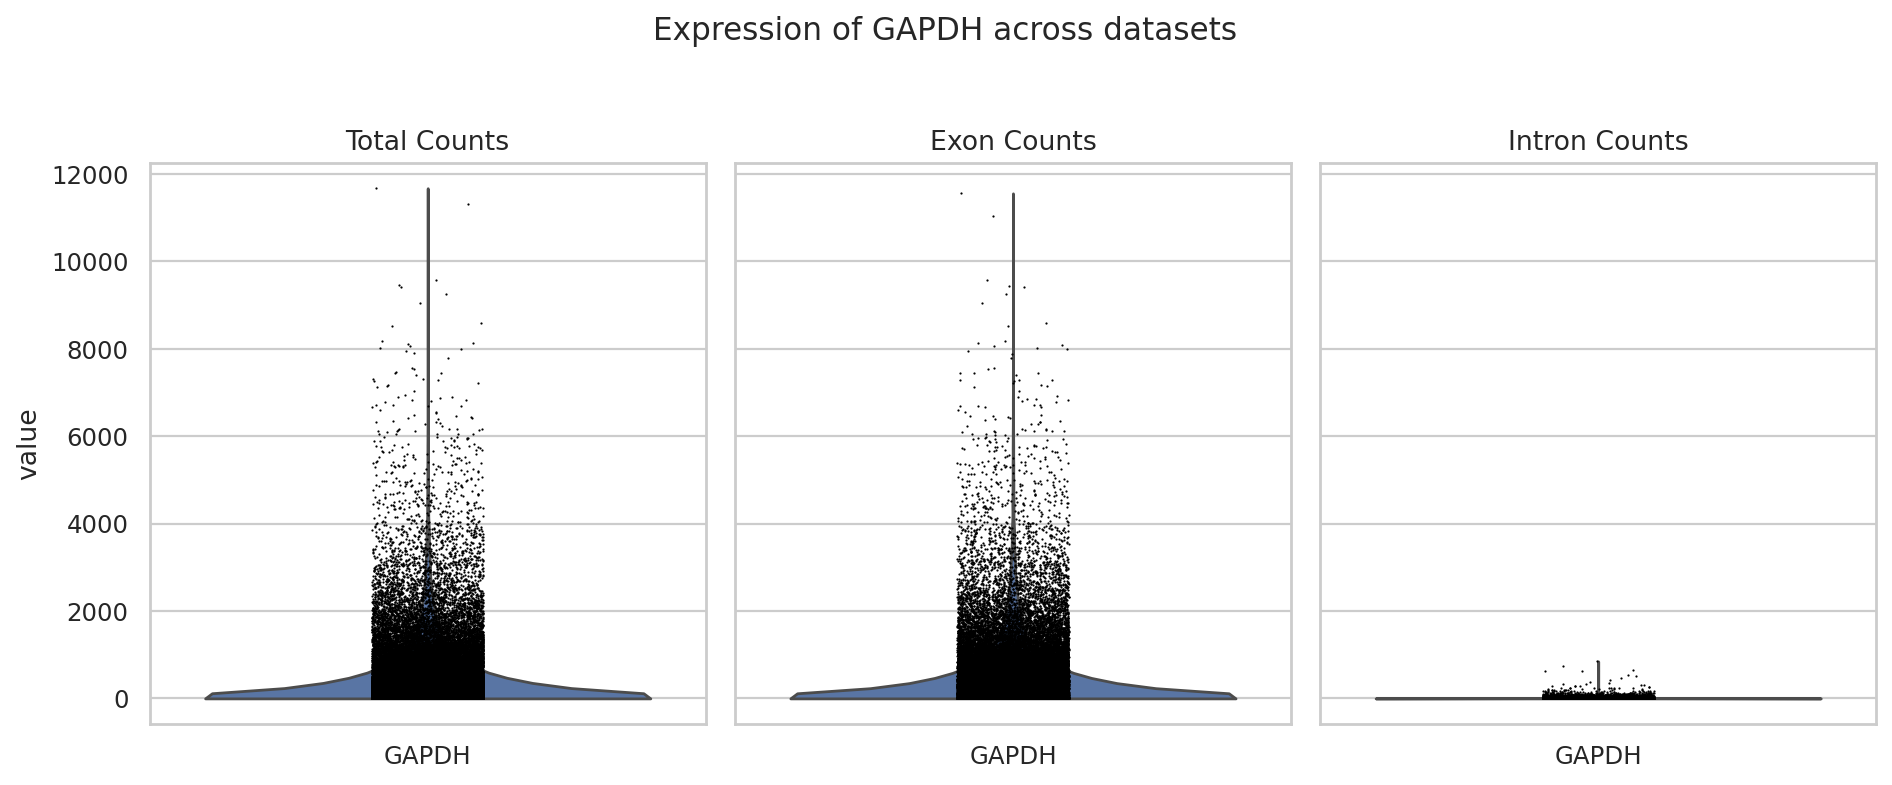

In [6]:
gene = "GAPDH"

# Create figure and subplots
fig, axs = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

# Total counts
sc.pl.violin(ab_adata, keys=gene, ax=axs[0], show=False)
axs[0].set_title("Total Counts")

# Exon counts
sc.pl.violin(ab_adata_exons, keys=gene, ax=axs[1], show=False)
axs[1].set_title("Exon Counts")

# Intron counts
sc.pl.violin(ab_adata_introns, keys=gene, ax=axs[2], show=False)
axs[2].set_title("Intron Counts")

# Super title
fig.suptitle(f"Expression of {gene} across datasets", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leaves space for the suptitle
plt.show()

Randomly sampled gene: ZNF37A


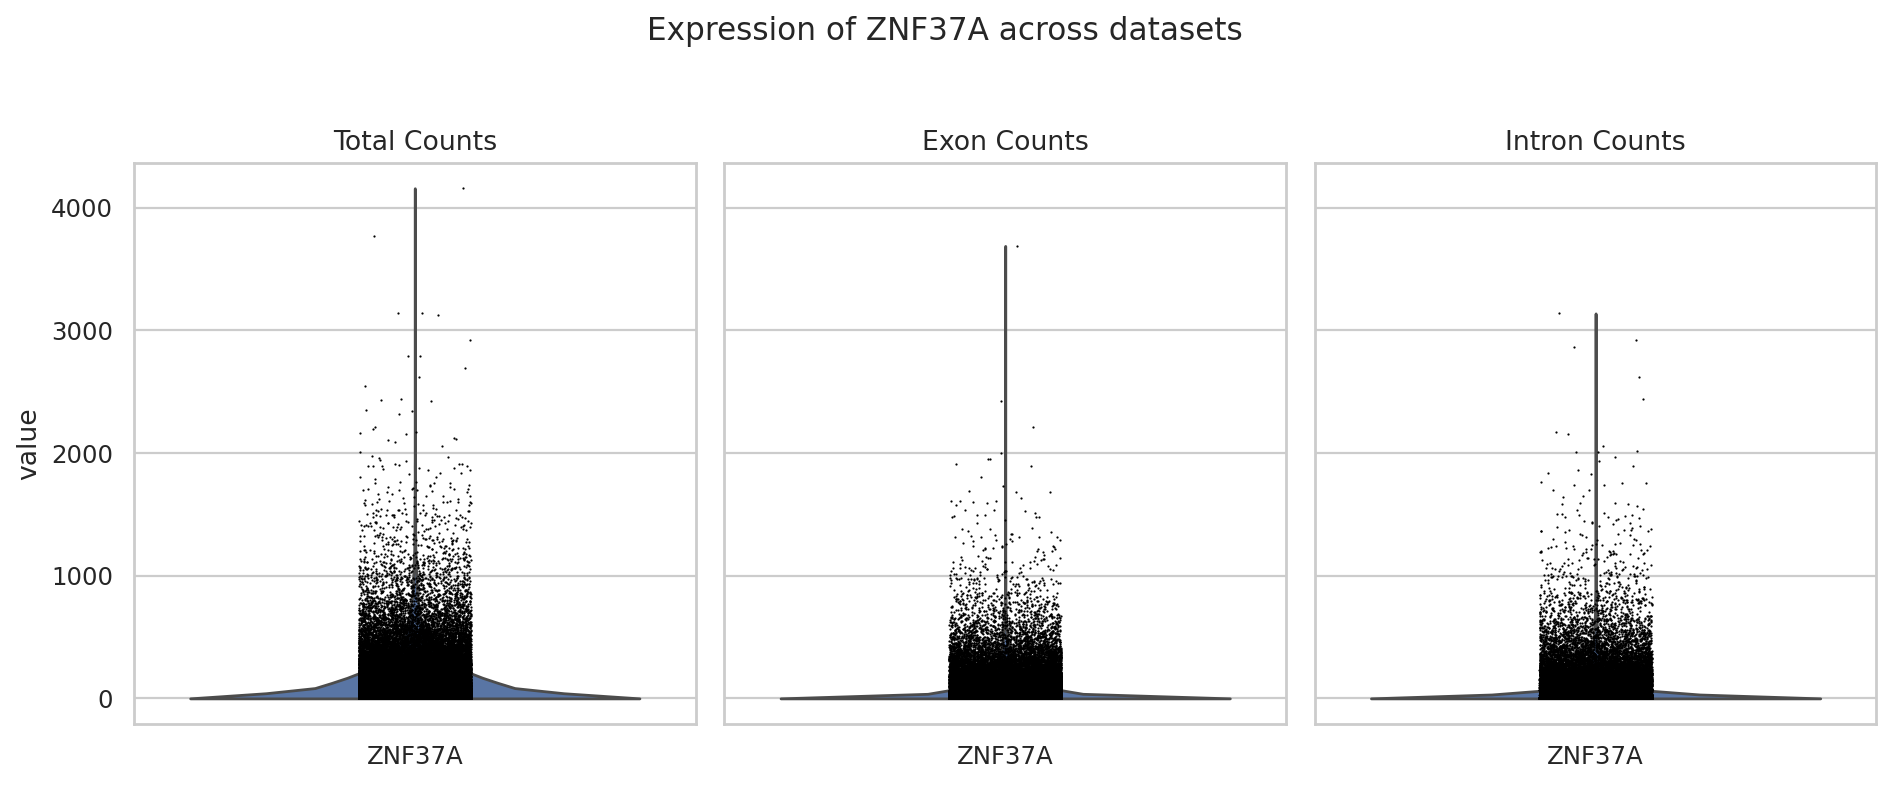

In [7]:
# sample a gene frmo ab_adata.var_names 
gene_samp = np.random.choice(ab_adata.var_names, 1)[0]
print(f"Randomly sampled gene: {gene_samp}")

# Create figure and subplots
fig, axs = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

# Total counts
sc.pl.violin(ab_adata, keys=gene_samp, ax=axs[0], show=False)
axs[0].set_title("Total Counts")

# Exon counts
sc.pl.violin(ab_adata_exons, keys=gene_samp, ax=axs[1], show=False)
axs[1].set_title("Exon Counts")

# Intron counts
sc.pl.violin(ab_adata_introns, keys=gene_samp, ax=axs[2], show=False)
axs[2].set_title("Intron Counts")

# Super title
fig.suptitle(f"Expression of {gene_samp} across datasets", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leaves space for the suptitle
plt.show()

### Read in the Tabula Sapien V2 dataset (SS2 cells only!)

In [8]:
# load in tabula sapien data 
# tabsap_adata = sc.read_h5ad("/gpfs/commons/datasets/controlled/CZI/tabula-sapiens/TS_figshare/TabulaSapiens.h5ad") # original tabula sapiens 
print(f"Now reading in Tabula Sapiens V2 data...")
tabsap_adata = sc.read_h5ad("/gpfs/commons/datasets/controlled/CZI/tabula-sapiens/TabulaSapiens_v2/GeneExpressionMatrices/merged_tabula_sapiens.h5ad")
tabsap_adata.obs["dataset"] = "tabula_sapiens"
tabsap_adata.layers["raw_counts"] = tabsap_adata.X.copy()
print("Number of genes in common between the two datasets:", len(set(tabsap_adata.var["gene_symbol"]).intersection(set(ab_adata.var["gene_symbol"]))))
print("Number of duplicated gene symbols in tabsap_adata:", tabsap_adata.var["gene_symbol"].duplicated().sum())
# Find the rows in tabsap_adata.var that are duplicated
duplicated_genes = tabsap_adata.var[tabsap_adata.var["gene_symbol"].duplicated(keep=False)]
# Remove the duplicated genes from tabsap_adata.var
tabsap_adata = tabsap_adata[:, ~tabsap_adata.var.index.isin(duplicated_genes.index)].copy()
print("Number of duplicated gene symbols in tabsap_adata:", tabsap_adata.var["gene_symbol"].duplicated().sum())
tabsap_adata.var["gene_name"] = tabsap_adata.var["gene_symbol"]
tabsap_adata = tabsap_adata[:, tabsap_adata.var["gene_name"].isin(gene_info_df["gene_name"])].copy()

Now reading in Tabula Sapiens V2 data...
Number of genes in common between the two datasets: 30547
Number of duplicated gene symbols in tabsap_adata: 1200
Number of duplicated gene symbols in tabsap_adata: 0


In [9]:
def normalize_and_combine(ab_adata, tabsap_adata_orig, gene_info_df, mode="transcript"):
    """
    Normalize Allen Brain and Tabula Sapiens adatas using gene length and concatenate them.
    """
    
    # Make copies to avoid modifying originals
    ab = ab_adata.copy()
    ts = tabsap_adata_orig.copy()

    print("🔍 Checking duplicates...")
    print("Duplicated gene symbols in ab:", ab.var["gene_symbol"].duplicated().sum())

    # Check if "gene_name" column is in ab.var otherwise make one and set values in it to ab.var["gene_symbol"]
    if "gene_name" not in ab.var.columns:
        ab.var["gene_name"] = ab.var["gene_symbol"]

    # Keep only genes with gene length info
    ab = ab[:, ab.var["gene_name"].isin(gene_info_df["gene_name"])].copy()
    ab.var = ab.var.merge(gene_info_df, on="gene_name")

    ts = ts[:, ts.var["gene_name"].isin(gene_info_df["gene_name"])].copy()
    ts.var = ts.var.merge(gene_info_df, on="gene_name")

    # Subset to common genes
    common_genes = set(ts.var["gene_name"]).intersection(set(ab.var["gene_name"]))
    ab = ab[:, ab.var["gene_name"].isin(common_genes)].copy()
    ts = ts[:, ts.var["gene_name"].isin(common_genes)].copy()

    # Reset and set gene_symbol index
    ab.var = ab.var.reset_index()
    ts.var = ts.var.reset_index()

    ab.var["gene_symbol"] = ab.var["gene_symbol"].astype(str)
    ts.var["gene_symbol"] = ts.var["gene_symbol"].astype(str)

    ab.var = ab.var.set_index("gene_symbol")
    ts.var = ts.var.set_index("gene_symbol")

    # Match order
    ts = ts[:, ab.var_names].copy()
    assert (ab.var_names == ts.var_names).all()

    print(f"Normalizing using {mode} length... for Allen Brain (single nuclei)")
    length_col = "mean_transcript_length" if mode == "transcript" else "mean_intron_length"
    median_length = np.median(ab.var[length_col].values)
    print(f"Median length is {median_length}")
    ab.X = ab.X / ab.var[length_col].values * median_length

    # get ts median length because for that it should always be full trancsript
    print(f"Normalizing using average transcript length... for Tabula Sapiens (single cell)")
    median_length = np.median(ts.var["mean_transcript_length"].values)
    ts.X = ts.X / ts.var["mean_transcript_length"].values * median_length

    ab.X = np.rint(ab.X)
    ts.X = np.rint(ts.X)

    ab.layers["gene_length_normalized"] = ab.X.copy()
    ts.layers["gene_length_normalized"] = ts.X.copy()

    # Drop unnecessary columns
    ab.var.drop(columns=["index", "gene_id"], errors="ignore", inplace=True)
    ts.var.drop(columns=["index", "gene_id", "mean", "std"], errors="ignore", inplace=True)

    # Ensure no sparse layers
    for layer in ts.layers:
        if sp.issparse(ts.layers[layer]):
            ts.layers[layer] = ts.layers[layer].tocsr()

    # Cell type annotations
    ab.obs["cell_type_combined"] = ab.obs["subclass_label"]
    ts.obs["cell_type_combined"] = ts.obs["free_annotation"]

    # Remove cells with missing annotations
    cells_unknown = ab.obs[ab.obs["cell_type_combined"].isna()].index
    print(f"Removing {len(cells_unknown)} unknown cells from Allen Brain...")
    ab = ab[~ab.obs.index.isin(cells_unknown)].copy()

    # Concatenate
    combined = ab.concatenate(ts, batch_key="dataset")
    combined.X = combined.layers["gene_length_normalized"].copy()  # <-- this line is key

    print("Combined shape:", combined.shape)
    return combined

In [10]:
# Keep both AB and TS aligned for each version
paired_versions = {
    "total": {"ab": ab_adata, "ts": tabsap_adata.copy()},
    "exons": {"ab": ab_adata_exons, "ts": tabsap_adata.copy()},
    "introns": {"ab": ab_adata_introns, "ts": tabsap_adata.copy()}
}

ab_versions = {
    "total": ab_adata,
    "exons": ab_adata_exons,
    "introns": ab_adata_introns
}

modes = {
    "total": "transcript",
    "exons": "transcript",
    "introns": "intron"
}

gene_info_df = gene_info_df.drop_duplicates(subset="gene_name")
print("The number of unique genes in the gene_info_df is:", gene_info_df["gene_name"].nunique())

combined_versions = {}
for version, ab in ab_versions.items():
    print(f"\n Processing version: {version}")
    combined_versions[version] = normalize_and_combine(
        ab, tabsap_adata, gene_info_df, mode=modes[version]
    )

The number of unique genes in the gene_info_df is: 61617

 Processing version: total
🔍 Checking duplicates...
Duplicated gene symbols in ab: 0


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Normalizing using transcript length... for Allen Brain (single nuclei)
Median length is 1255.0
Normalizing using average transcript length... for Tabula Sapiens (single cell)


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Removing 1985 unknown cells from Allen Brain...


...

Normalizing using average transcript length... for Tabula Sapiens (single cell)


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Removing 1985 unknown cells from Allen Brain...


/scratch/ipykernel_1874012/3831504459.py:79: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined = ab.concatenate(ts, batch_key="dataset")


Combined shape: (88933, 30340)


In [11]:
# reorder so introns is first combined_versions
combined_versions = {
    "introns": combined_versions["introns"],
    "exons": combined_versions["exons"],
    "total": combined_versions["total"]
}

In [ ]:
# Grouped mappings by broad cell type
grouped_broad_map = {
    'Neuron': [
        'IT', 'L4 IT', 'VIP', 'PVALB', 'SST', 'L6 CT', 'L6b', 'L5 ET', 'L5/6 IT Car3',
        'L5/6 NP', 'PAX6', 'LAMP5', 'retinal bipolar neuron'
    ],
    'T cell': [
        'cd4-positive, alpha-beta t cell', 'cd8-positive, alpha-beta t cell', 't cell',
        'regulatory t cell', 'cd4-positive helper t cell', 'cd4-positive, alpha-beta memory t cell',
        'cd8-positive, alpha-beta memory t cell', 'naive thymus-derived cd4-positive, alpha-beta t cell',
        'activated cd4-positive, alpha-beta t cell', 'cd8-positive, alpha-beta thymocyte',
        'naive cd8-positive t cell', 'cd4-positive, alpha-beta thymocyte', 'gamma-delta t cell',
        'cd4-positive memory t cell', 'activated cd8-positive, alpha-beta t cell',
        't follicular helper cell', 'naive regulatory t cell', 'thymocyte',
        'cd8-positive cytotoxic t cell', 'cd8+, alpha-beta cytokine secreting effector t cell'
    ],
    'B cell': ['b cell', 'memory b cell', 'plasma cell', 'naive b cell'],
    'Microglia_Macrophage': [
        'macrophage', 'Microglia', 'microglial cell', 'Monocyte_Macrophage',
        'tissue-resident macrophage', 'muscle macrophage', 'retina - microglia'
    ],
    'Monocyte': [
        'monocyte', 'classical monocyte', 'non-classical monocyte', 'intermediate monocyte'
    ],
    'NK/ILC': [
        'nk cell', 'natural killer cell', 'nk t cell', 'innate lymphoid cell', 'mature nk t cell',
        'type i nk t cell', 'uterine nk cell', 'proliferating nk cell', 'immature natural killer cell'
    ],
    'Dendritic': [
        'dendritic cell', 'myeloid dendritic cell', 'plasmacytoid dendritic cell',
        'cd1c-positive myeloid dendritic cell', 'cd141-positive myeloid dendritic cell',
        'cdc1', 'cdc2', 'conventional dendritic cell'
    ],
    'Granulocyte': [
        'neutrophil', 'cd24 neutrophil', 'nampt neutrophil', 'granulocyte',
        'basophil', 'mast cell'
    ],
    'Epithelial': [
        'epithelial cell', 'club cell', 'ionocyte', 'duct epithelial cell', 'goblet cell',
        'ltf+ epithelial cell', 'ciliated epithelial cell', 'basal epithelial cell',
        'bladder urothelial cell', 'basal bladder urothelial cell', 'intermediate bladder urothelial cell',
        'enterocyte of epithelium of large intestine', 'enterocyte of epithelium proper of small intestine',
        'salivary gland cell', 'HR positive luminal epithelial cell of mammary gland',
        'epithelial cell of uterus', 'pulmonary ionocyte', 'large intestine goblet cell',
        'medullary thymic epithelial cell', 'antibody secreting cell', 'conjunctival epithelial cell',
        'corneal epithelial cell', 'secretory luminal epithelial cell of mammary gland',
        'glandular epithelial cell', 'luminal epithelial cell', 'cycling epithelial cell',
        'mucus secreting cell', 'serous cell of epithelium of bronchus', 'best4+ intestinal epithelial cell',
        'biliary epithelial cell', 'pancreatic ductal cell', 'small intestine goblet cell',
        'stratified squamous epithelial cell', 'sebum secreting cell', 'enterocyte of epithelium proper of ileum',
        'enterocyte of epithelium proper of duodenum', 'paneth cell of epithelium of small intestine',
        'paneth cell of colon', 'mature enterocyte', 'intestinal tuft cell',
        'tuft cell of colon'
    ],
    'Endothelial': [
        'endothelial cell', 'capillary endothelial cell', 'arterial endothelial cell',
        'vein endothelial cell', 'endothelial cell of vascular tree', 'endothelial cell of lymphatic vessel',
        'cardiac endothelial cell', 'colon endothelial cell', 'retinal blood vessel endothelial cell',
        'endothelial cell of arteriole', 'venous capillary endothelial cell', 'blood vessel endothelial cell',
        'endothelial cell of venule', 'endothelial cell of artery', 'vascular endothelial cell'
    ],
    'Glia': [
        'Astrocyte', 'OPC', 'Oligodendrocyte', 'retina - muller glia', 'mueller cell',
        'enteroglial cell', 'schwann cell', 'glial cell'
    ],
    'Muscle': [
        'smooth muscle cell', 'skeletal muscle satellite stem cell', 'fast muscle cell',
        'slow muscle cell', 'atrial cardiac muscle cell', 'muscle cell', 'tongue muscle cell',
        'ventricular cardiac muscle cell', 'airway smooth muscle cell', 'tendon cell',
        'vascular associated smooth muscle cell'
    ],
    'Stromal': [
        'fibroblast', 'stromal cell', 'myofibroblast cell', 'adventitial fibroblast', 'cd34+ fibroblasts',
        'VLMC', 'fat cell', 'adventitial cell', 'cornea - mesenchymal cell - stromal keratinocytes',
        'limbal stromal cell', 'follicle', 'granulosa cell', 'mesothelial cell', 'theca cell',
        'connective tissue cell', 'endometrial stromal fibroblast'
    ],
    'Fibroblast': [
        'alveolar fibroblast', 'fibroblast of breast', 'fibroblast of cardiac tissue', 'uterine fibroblast',
        'stellate_fibroblast'
    ],
    'Pericyte': [
        'pericyte', 'Pericyte', 'myofibroblast cell and pericyte', 'mural cell'
    ],
    'Liver': [
        'hepatocyte', 'hepatic stellate cell', 'intrahepatic cholangiocyte'
    ],
    'Photoreceptor': [
        'retinal pigment epithelial cell', 'retina - photoreceptor cell', 'eye photoreceptor cell'
    ],
    'Alveolar cell': [
        'type ii pneumocyte', 'type i pneumocyte', 'capillary aerocyte', 'respiratory goblet cell',
        'ciliated columnar cell of tracheobronchial tree', 'tracheal goblet cell'
    ],
    'Endocrine': [
        'enteroendocrine cell of small intestine', 'type l enteroendocrine cell', 'enterochromaffin-like cell'
    ],
    'Hematopoietic': [
        'platelet', 'erythroid progenitor cell', 'erythrocyte'
    ],
    'Stem/Progenitor': [
        'hematopoietic stem cell', 'mesenchymal stem cell', 'myeloid progenitor', 'common myeloid progenitor',
        'mesenchymal stem cell of adipose tissue'
    ],
    'Progenitor': [
        'oocyte', 'radial glia progenitor cell', 'intestinal crypt stem cell of small intestine',
        'intestinal crypt stem cell of large intestine'
    ],
    'Secretory': [
        'acinar cell of salivary gland', 'lacrimal gland functional unit cell', 'myoepithelial cell'
    ],
    'Pigment cell': [
        'melanocyte', 'melanocyte or limbal stem cell'
    ],
    'Sensory': [
        'taste receptor cell'
    ],
    'Skin': [
        'keratocyte'
    ],
    'Myeloid': [
        'myeloid cell', 'mononuclear phagocyte'
    ],
    'Immune other': [
        'leukocyte', 'langerhans cell', 'immune cell'
    ],
    'Unknown': [
        'unknown'
    ],
}

# 1. Define flatten function once
def flatten_grouped_map(grouped_map):
    return {label: broad_type for broad_type, labels in grouped_map.items() for label in labels}

# 2. Create the flat map once (outside the loop)
broad_celltype_map = flatten_grouped_map(grouped_broad_map)

In [14]:
# 3. Iterate through versions
for version, combined in combined_versions.items():
    print(f"\n🚀 Processing version: {version.upper()}")

    # Map broad cell types
    combined.obs['broad_cell_type'] = (
        combined.obs['cell_type_combined'].map(broad_celltype_map).fillna('Other')
    )

    # Fix dataset labels
    combined.obs["dataset"] = combined.obs["dataset"].astype(str).replace({
        "0": "single_nuclei_AB",
        "1": "single_cell_TS"
    })

    # Determine shared cell types with at least 50 cells per dataset
    broad_counts = (
        combined.obs.groupby(["dataset", "broad_cell_type"])
        .size().reset_index(name="count")
    )
    pivot_counts = broad_counts.pivot(index="broad_cell_type", columns="dataset", values="count").fillna(0)
    shared_broad_cell_types = pivot_counts[(pivot_counts >= 50).all(axis=1)].index.tolist()
    
    print(f"✔️ Shared broad cell types (≥50 per dataset): {shared_broad_cell_types}")

    # Tag shared types
    combined.obs["shared_broad_cell_type"] = (
        combined.obs["broad_cell_type"].apply(lambda x: x if x in shared_broad_cell_types else "Other")
    ).astype("category")

    # ensure no NaN values in combined.X
    if sp.issparse(combined.X):
        combined.X.data[np.isnan(combined.X.data)] = 0
    else:
        combined.X[np.isnan(combined.X)] = 0

    # print which cells have combined values that are NaN
    print(combined.X.data[np.isnan(combined.X.data)])
    sc.pp.normalize_total(combined, target_sum=1e4)
    sc.pp.log1p(combined)

    # Highly variable genes (using CPU Scanpy)
    sc.pp.highly_variable_genes(
        combined, flavor="seurat_v3", n_top_genes=2000, layer="gene_length_normalized",
        batch_key="dataset", subset=False
    )
    sc.pp.pca(combined)

    # UMAP before Harmony
    sc.pp.neighbors(combined, use_rep="X_pca")
    sc.tl.umap(combined)

    # Silhouette Scores (PCA)
    sil_dataset = silhouette_score(combined.obsm["X_pca"], combined.obs["dataset"])
    print(f"📊 PCA Silhouette - Dataset: {sil_dataset:.3f}")



🚀 Processing version: INTRONS
✔️ Shared broad cell types (≥50 per dataset): ['Glia', 'Microglia_Macrophage', 'Other']
[]
normalizing counts per cell
    finished (0:00:01)


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/_utils/__init__.py:622: RuntimeWarning: invalid value encountered in divide
  return op(x.data, np.repeat(scaling_array, np.diff(x.indptr)))


ValueError: Input contains NaN.

In [ ]:
combined_versions

In [ ]:
for version, combined in combined_versions.items():

    # --- PLOTS: Pre-Harmony ---
    sc.pl.umap(
        combined,
        color="shared_broad_cell_type",
        title=f"Pre-Harmony UMAP: Shared Cell Types ({version})"
    )
    sc.pl.umap(
        combined,
        color="dataset",
        title=f"Pre-Harmony UMAP: Dataset ({version})"
    )

    # --- Harmony Integration (CPU-based) ---
    print("Running Harmony integration on CPU...")
    sce.pp.harmony_integrate(combined, key="dataset")
    sc.pp.neighbors(combined, use_rep="X_pca_harmony", n_neighbors=10, n_pcs=30)
    sc.tl.umap(combined)
    sc.tl.leiden(combined, resolution=0.5)

    # Silhouette scores after Harmony (CPU)
    harmony_dataset = silhouette_score(combined.obsm["X_pca_harmony"], combined.obs["dataset"])
    print(f"Harmony Silhouette - Dataset: {harmony_dataset:.3f}")

    # --- PLOTS: Post-Harmony ---
    sc.pl.umap(
        combined,
        color="shared_broad_cell_type",
        title=f"Post-Harmony UMAP: Shared Cell Types ({version})"
    )
    sc.pl.umap(
        combined,
        color="dataset",
        title=f"Post-Harmony UMAP: Dataset ({version})"
    )
    

### to:do --> can do microglia/macrophage comparison, if pseudobulk these two can plot genes as points, plot length normalized expression for TS vs different ways of allen brain norm (total counts, exon only, intron only, separatley normalized exon + intron) to assess correlation of expected marker genes in these two similar cell types

In [ ]:
# save tabula sapien metadata to easily link back with BAM files and junction files 
output_dir = "/gpfs/commons/datasets/controlled/CZI/tabula-sapiens/TabulaSapiens_v2/"
ts_metadata = tabsap_adata.obs[["old_index", "donor", "tissue", "anatomical_position", "library_plate", "cdna_well", "assay"]]
# save metadata to file
ts_metadata.to_csv(os.path.join(output_dir, "metadata.csv"), index=False)

In [ ]:
# get list of microglia/macrophage marker genes 
# sample 100 random marker genes from other cell types 
mg_macro_markers = [
    'AIF1', 'CD68', 'CX3CR1', 'P2RY12', 'TMEM119', 'SALL1', # Microglia-biased
    'MRC1', 'CD163', 'CCR2', 'LYVE1', # Macrophage-biased (context-dependent)
    'SPI1', 'CSF1R', 'ADGRE1', # General myeloid 
    'CD14', 'CD80', 'CD115', 'CD206', 'HLA-DR', 'CSF-1R', 'CD163' 
    # Add more relevant genes from literature / prior analysis
]
# Ensure markers exist in the data
mg_macro_markers = [g for g in mg_macro_markers if g in combined.var_names]
print(f"🧬 Using {len(mg_macro_markers)} Microglia/Macrophage markers found in data.")

In [ ]:
for version, combined in combined_versions.items():

    # Obtain just cells with "Microglia_Macrophage" label under "shared_broad_cell_type" 
    mg_macro_cells = combined.obs[combined.obs["shared_broad_cell_type"] == "Microglia_Macrophage"].index
    
    # Now split by dataset 
    mg_macro_cells_ab = mg_macro_cells[combined.obs.loc[mg_macro_cells, "dataset"] == "single_nuclei_AB"]
    mg_macro_cells_ts = mg_macro_cells[combined.obs.loc[mg_macro_cells, "dataset"] == "single_cell_TS"]
    
    # Let's turn this into a pseudobulk sample by combining raw counts for every gene in each group of cells 
    # Ensure that X in combined corresponds to the raw counts 
    combined.X = combined.layers["raw_counts"].copy()
    mg_macro_cells_ab_pseudobulk = combined[mg_macro_cells_ab, :].X.sum(axis=0)
    
    # Get the expression data for these cells 
    mg_macro_ab = combined[mg_macro_cells_ab, :].copy()
    mg_macro_ts = combined[mg_macro_cells_ts, :].copy()

    # Get the expression data for the marker genes
    mg_macro_ab = mg_macro_ab[:, mg_macro_markers].copy()
    mg_macro_ts = mg_macro_ts[:, mg_macro_markers].copy()

    # Get the mean expression for each marker gene
    mg_macro_ab_mean = mg_macro_ab.X.mean(axis=0) # mean value by marker gene 
    mg_macro_ts_mean = mg_macro_ts.X.mean(axis=0) # mean value by marker geneß

    # Combine the mean expression data into a DataFrame 
    mg_macro_df = pd.DataFrame({
        "marker_gene": mg_macro_markers,
        "mean_expression_AB": mg_macro_ab_mean.A.flatten(),
        "mean_expression_TS": mg_macro_ts_mean.A.flatten()
    })

    print(mg_macro_df)

    # Plot correlation of mean values 
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=mg_macro_df, x="mean_expression_AB", y="mean_expression_TS")
    plt.title(f"Microglia/Macrophage Marker \nGene Expression Correlation ({version})")
    plt.xlabel("Mean Expression (AB)")
    plt.ylabel("Mean Expression (TS)")
    # Draw correlation line 
    sns.regplot(data=mg_macro_df, x="mean_expression_AB", y="mean_expression_TS", scatter=False, color='red')
    plt.grid()
    plt.show()
    

In [ ]:
for version, combined in combined_versions.items():
    # Plot UMAP and color by "shared_broad_cell_type", "class_label",  "subclass_label", "tissue" and "dataset" in one column 
    sc.pl.umap(
        combined,
        color=["shared_broad_cell_type", "class_label", "subclass_label", "tissue", "dataset"],
        ncols=1
    )


In [ ]:
for version, combined in combined_versions.items():

    # subset combined_versions["total"] to just "shared_broad_cell_type" == "Microglia_Macrophage"
    combined_mg_macro = combined_versions[version][combined_versions[version].obs["shared_broad_cell_type"] == "Microglia_Macrophage"].copy()

    # let's just keep from cell_type_combined column macrophage + Microglia 
    combined_mg_macro = combined_mg_macro[combined_mg_macro.obs["cell_type_combined"].isin(["macrophage", "Microglia"])]
    print(combined_mg_macro.obs["cell_type_combined"].value_counts())

    cell_type_palette = {
        "Microglia": "#1f77b4",
        "macrophage": "#ff7f0e",
        # add other types if needed
    }

    dataset_palette = {
        "single_cell_TS": "#ff7f0e",
        "single_nuclei_AB": "#1f77b4",
        # add more if needed
    }

    sc.pl.umap(
        combined_mg_macro,
        color="cell_type_combined",
        title=(f"Microglia/Macrophage UMAP: Cell Types ({version})"),
        palette=cell_type_palette,
        alpha=0.6
    )

    sc.pl.umap(
        combined_mg_macro,
        color="dataset",
        title=(f"Microglia/Macrophage UMAP: Dataset ({version})"), 
        palette=dataset_palette,
        alpha=0.6
    )

    # make another plot by color by "tissue" 
    sc.pl.umap(
        combined_mg_macro,
        color="tissue",
        title=(f"Microglia/Macrophage UMAP: Tissue ({version})"), 
        alpha=0.6
    )

    sc.pl.stacked_violin(combined_mg_macro, mg_macro_markers, groupby='cell_type_combined', dendrogram=True, title=f"Microglia/Macrophage Stacked Violin ({version})")

In [ ]:
# sample a gene frmo ab_adata.var_names 
gene_samp = np.random.choice(combined_versions["introns"].var_names, 1)[0]
print(f"Randomly sampled gene: {gene_samp}")

gene_samp = "GAPDH"
# Total counts
sc.pl.violin(combined_versions["introns"], groupby="dataset", keys=gene_samp, show=False)

In [ ]:
gene_samp = "GAPDH"
# Total counts
sc.pl.violin(combined_versions["exons"], groupby="dataset", keys=gene_samp, show=False)
# Total counts
sc.pl.violin(combined_versions["total"], groupby="dataset", keys=gene_samp, show=False)

In [ ]:
mg_macro_markers

In [ ]:
microglia_unique = ["TMEM119", "P2RY12", "SALL1"]